In [1]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MCsamps(fname, param_acorr='sigma8', acorr_min=0.0, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.1, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$',
    'alphasat_Nsat':r'$\alpha_{\rm sat}$',
    'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
    'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
    'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
    'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
    'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
    'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
    'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    ind_gr = ind_sigma8
    gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    print(gr)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
    marge = samples.getMargeStats()
    # for j1 in range(len(names)):
        # paramj1 = names[j1]
        # r_marge = marge.parWithName(paramj1)
        # r_mean = r_marge.mean
        # print(paramj1 + ': ' + str(r_mean) + ', ' + str(r_mean - r_marge.limits[0].lower) + ', ' + str(r_marge.limits[0].upper -  r_mean))

    return samples




In [15]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'

samps_all = get_MCsamps(ldir + 'mcmc_v2_all_samples_10000_warmup_4000_num_chains_96_treedepth_4.pkl')
samps_kkgggkge = get_MCsamps(ldir + 'mcmc_v2_kk_gg_gk_ge_samples_10000_warmup_4000_num_chains_96_treedepth_4.pkl')
samps_kkgggk = get_MCsamps(ldir + 'mcmc_v2_kk_gg_gk_samples_10000_warmup_4000_num_chains_96_treedepth_4.pkl')



(423000, 29) (47, 9000, 29)
1.012891667966982
Removed no burn in
(567000, 29) (63, 9000, 29)
1.0081379436760782
Removed no burn in
(414000, 29) (46, 9000, 29)
1.0107718121618925
Removed no burn in


<Figure size 900x900 with 0 Axes>

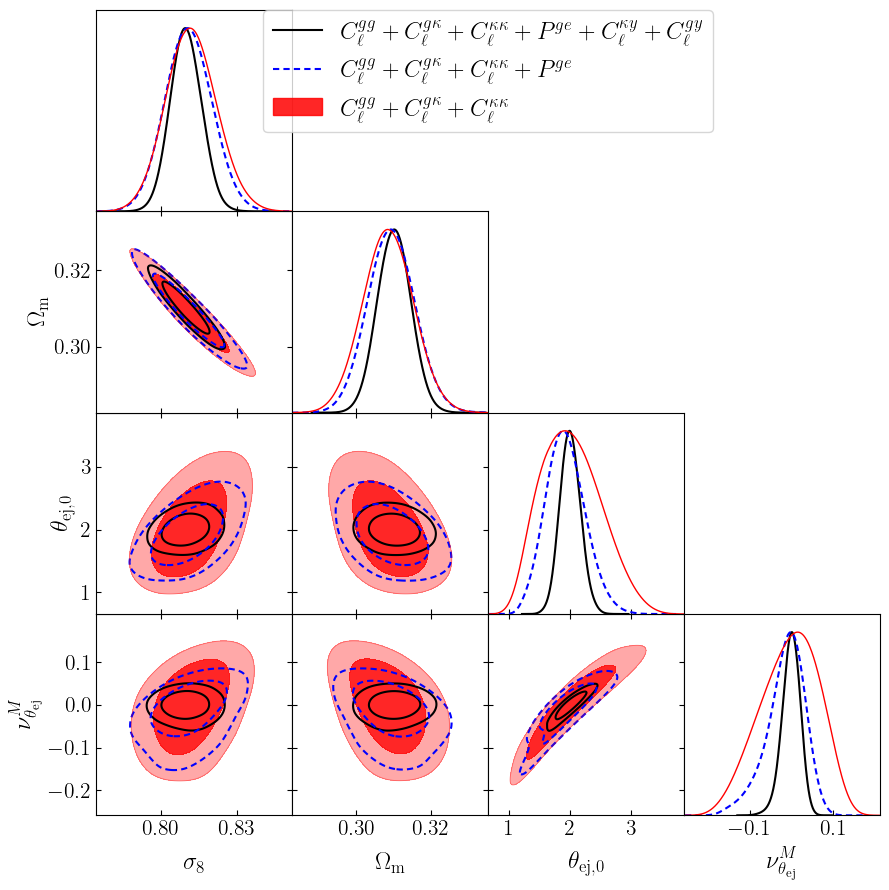

In [12]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=9.0, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


# samps_all = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_gty = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_gty_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
# samps_xipm = get_MCsamps(ldir + 'mcmc_v10_widemuej_nzfix_probe_xip_xim_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl')
params = samps_all.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_all, samps_kkgggkge, samps_kkgggk], ['sigma8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge} + C^{\kappa y}_{\ell} + C^{gy}_{\ell}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell}$'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()





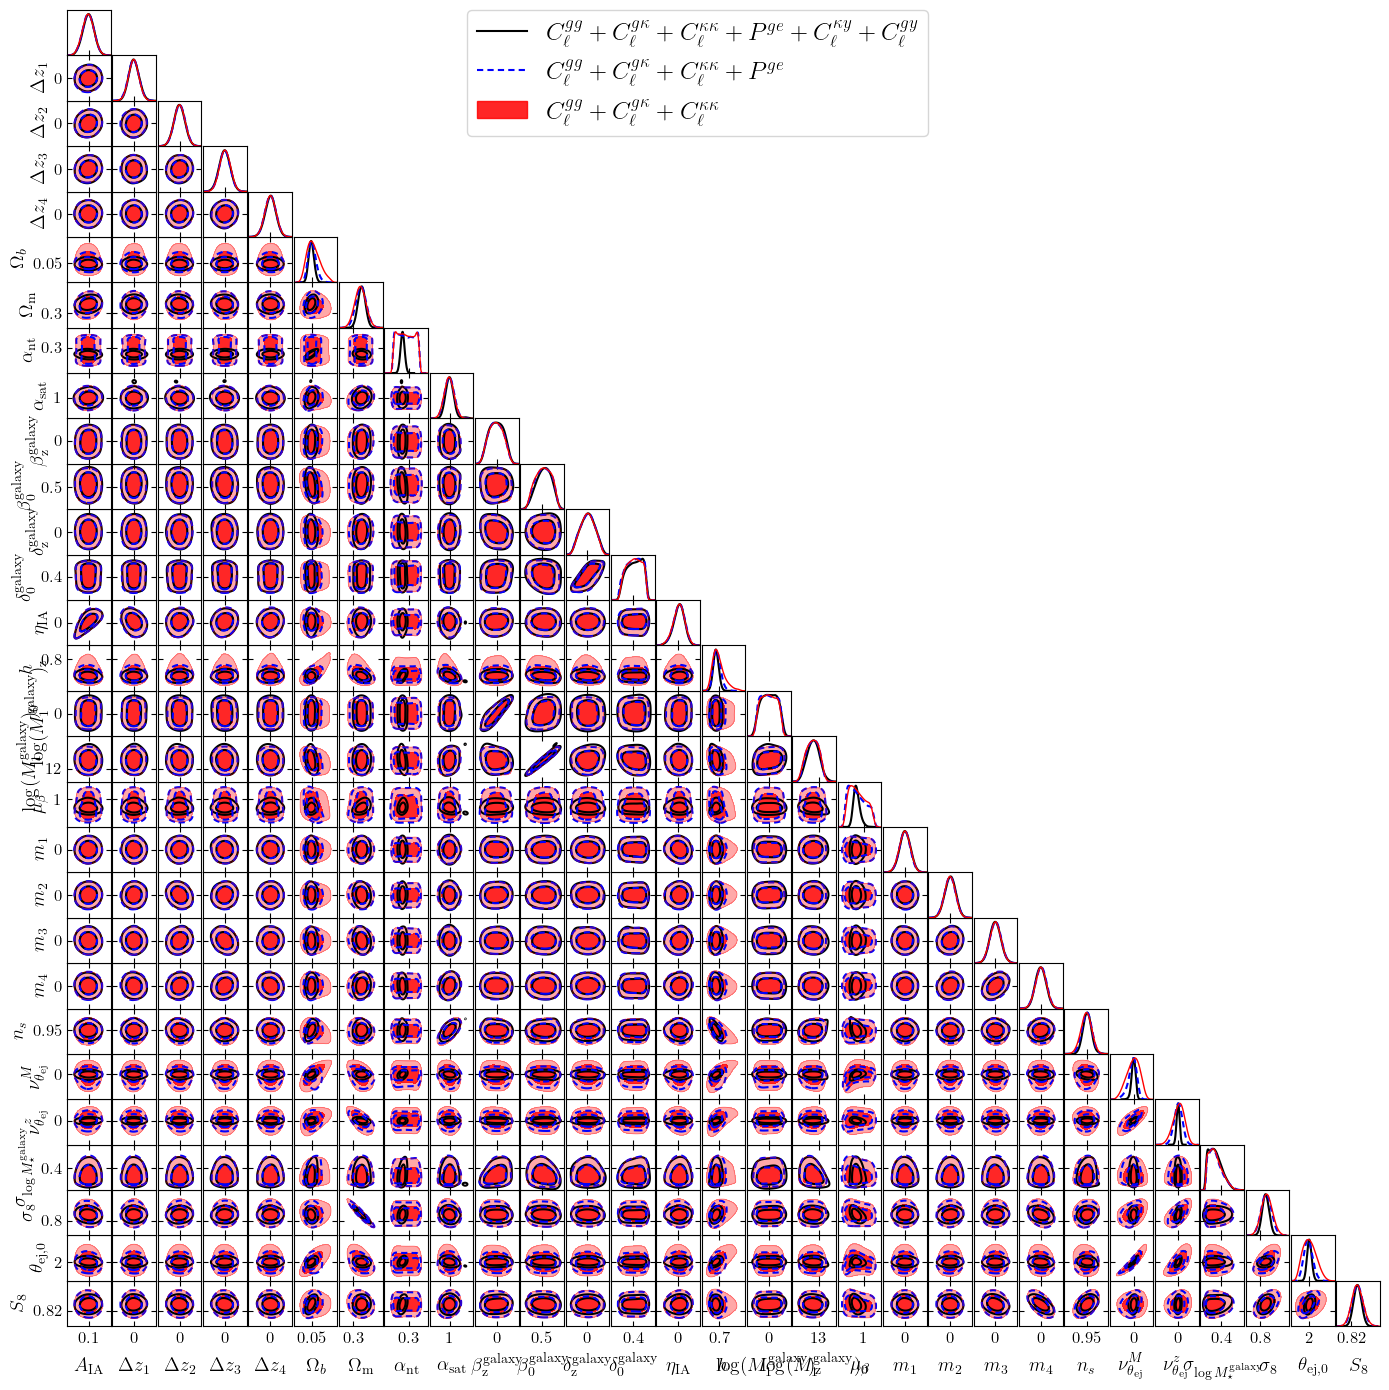

In [16]:
params = samps_all.getParamNames().getRunningNames()
g = plots.get_subplot_plotter(width_inch=14)
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 24
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


g.triangle_plot([samps_all, samps_kkgggkge, samps_kkgggk], params, line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge} + C^{\kappa y}_{\ell} + C^{gy}_{\ell}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell}$'])
# g.triangle_plot([samps_xipm_y3sc_dmb], params, filled=True)
save_plot_dir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
# g.export(save_plot_dir  + 'all_params_all_probes_fiducial_v2.pdf')
# g.export(save_plot_dir  + 'all_params_all_probes_fiducial_v2_widemuej.pdf')
g.export(save_plot_dir  + 'all_params_comp_ellmax_8000.pdf')
import matplotlib
%matplotlib inline
pl.show()


(45900, 29) (17, 2700, 29)
1.0397367317117332
Removed no burn in
(24300, 29) (9, 2700, 29)
1.031073143917476
Removed no burn in


(32400, 29) (12, 2700, 29)
1.0605836278242127
Removed no burn in
(21600, 29) (8, 2700, 29)
1.0082020044550395
Removed no burn in


<Figure size 900x900 with 0 Axes>

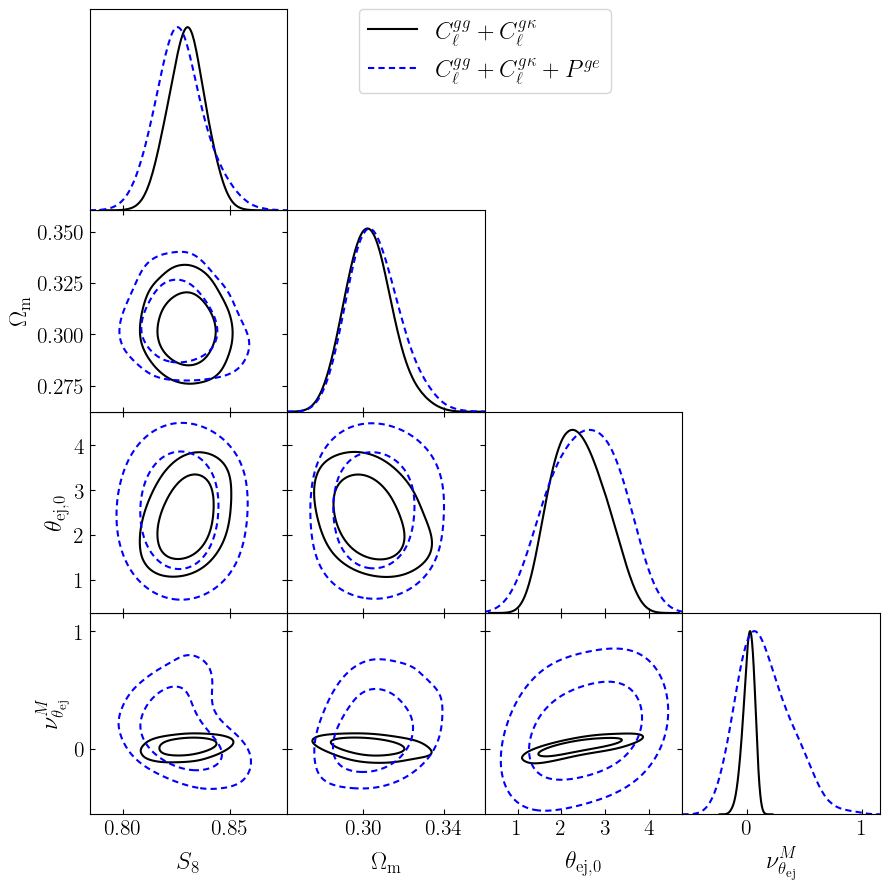

In [15]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'
lmax = 1000
samps_gg_gk_ge = get_MCsamps(ldir + f'/gg_gk_ge/mcmc_v2_gg_gk_ge_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')
samps_gg_gk = get_MCsamps(ldir + f'/gg_gk/mcmc_v2_gg_gk_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')


g = plots.getSinglePlotter(width_inch=9.0, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}

params = samps_gg_gk_ge.getParamNames().getRunningNames()

params_to_plot = ['S8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M']
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_gg_gk_ge, samps_gg_gk], params_to_plot, line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + P^{ge}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell}$'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()





(70200, 29) (26, 2700, 29)
1.0163863201494325
Removed no burn in
(29700, 29) (11, 2700, 29)
1.0486704727308636
Removed no burn in


<Figure size 900x900 with 0 Axes>

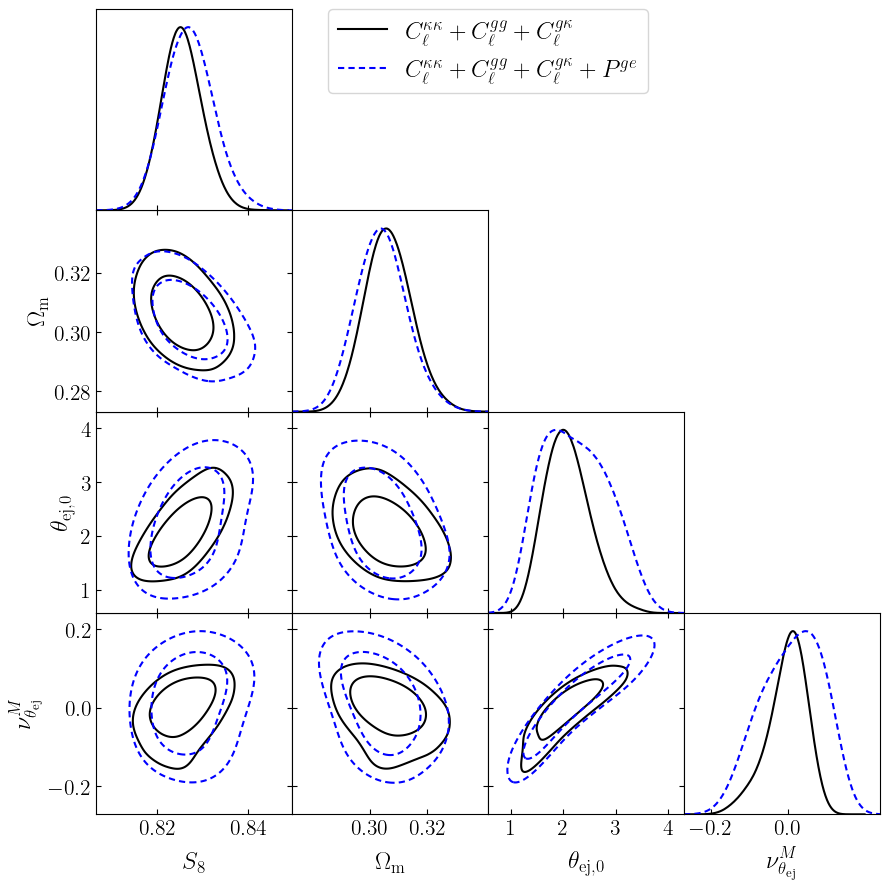

In [11]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'
lmax = 4000
samps_gg_gk_ge = get_MCsamps(ldir + f'/kk_gg_gk_ge/mcmc_v2_kk_gg_gk_ge_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')
samps_gg_gk = get_MCsamps(ldir + f'/kk_gg_gk/mcmc_v2_kk_gg_gk_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')


g = plots.getSinglePlotter(width_inch=9.0, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}

params = samps_gg_gk_ge.getParamNames().getRunningNames()

params_to_plot = ['S8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M']
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_gg_gk_ge, samps_gg_gk], params_to_plot, line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'$C^{\kappa \kappa}_{\ell} + C^{gg}_{\ell} + C^{g\kappa}_{\ell}$',
                                                        r'$C^{\kappa \kappa}_{\ell} + C^{gg}_{\ell} + C^{g\kappa}_{\ell} + P^{ge}$',
                                                        r'$C^{\kappa \kappa}_{\ell} + C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell}$'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()



